# Two Neuron Day 14 (29/01/2026)
***Phase 5- Day 5***

*Robustness & Sanity Checks*

**Neuron A**

In [187]:
import numpy as np
import matplotlib.pyplot as plt
#Time parameters
dt=0.1
T=100
time=np.arange(0,T,dt)

# Neuron A parameters
V_rest_A=-65
V_A=np.zeros(len(time))
V_A[0]=V_rest_A

#Input Current (constant)
I_A = 6
tau_A=10

# Spikes A
V_th_A = -63
V_reset_A = -65
spikes_A= np.zeros(len(time))

#Refractory period 
refractory_period_A = 2
refractory_steps_A = int(refractory_period_A / dt)
refractory_timer_A= 0

#Noise
noise_std = 1
noise = np.random.normal(0,noise_std,len(time))

#Voltage update loop
for t in range(1,len(time)):
    if refractory_timer_A >0:
        V_A[t] = V_reset_A
        refractory_timer_A -= 1

    else:
        I_t = I_A+noise[t]
        dV_A= (-(V_A[t-1] - V_rest_A ) + I_t) * (dt/tau_A)
        V_A[t] = V_A[t-1] + dV_A

        if V_A[t] >= V_th_A :
            spikes_A[t] = 1
            V_A[t] = V_reset_A
            refractory_timer_A = refractory_steps_A

#Firing rate calculation
total_spikes_A = np.sum(spikes_A)
total_time_sec_A= T/1000

firing_rate_A = total_spikes_A / total_time_sec_A
firing_rate_A

np.float64(160.0)

**Spike Count Neuron A**

In [188]:
spike_count_A = np.sum(spikes_A)
spike_count_A

np.float64(16.0)

**Neuron A Graph**

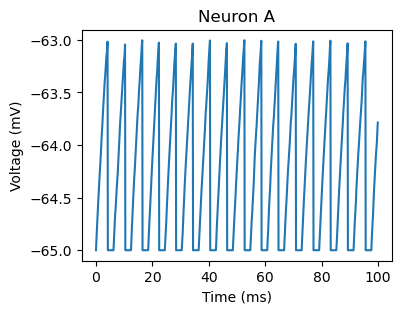

In [189]:
plt.figure(figsize=(4,3))
plt.plot(time,V_A)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Neuron A")
plt.show()

**Spike Train Neuron A**

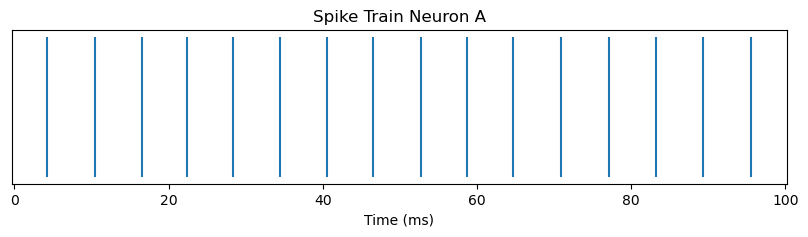

In [190]:
spike_times_A = time[spikes_A == 1]

plt.figure(figsize=(10,2))
plt.vlines(spike_times_A,ymin=0,ymax=1)
plt.xlabel("Time (ms)")
plt.yticks([])
plt.title("Spike Train Neuron A")
plt.show()

**Neuron B**

In [191]:
#Neuron A parameters 
V_rest_B = -65
V_B = np.zeros(len(time))
V_B[0] = V_rest_B

#Input Current (comes from Neuron A) 
# Synapthic connection from A-> B
w_AB = 15 + 10 * np.sin(2 * np.pi * np.arange(len(time)) / len(time))
I_B= np.zeros(len(time))
syn_current_B = np.zeros(len(time))

#Inhibitory synapse from A-> B
w_AiB = 4.0
syn_current_inh_B = np.zeros(len(time))

# Synaptic decay constants
alpha_exc = 0.90    # slow decay (excitation accumulates)
alpha_inh = 0.85    # faster decay (inhibition is brief)

#Spikes
V_th_B = -63
V_reset_B = -65
spikes_B = np.zeros(len(time))

#Refractory period
refractory_period_B = 2
refractory_steps_B = int(refractory_period_B / dt)
refractory_timer_B =0

# Voltage update loop for Neuron B
for t in range(1,len(time)):
    # Excitatory synapse (A -> B)
    syn_current_B[t] = (
        alpha_exc * syn_current_B[t-1]
        + w_AB[t] * spikes_A[t-1]
    )

    # Inhibitory synapse (A -> B)
    syn_current_inh_B[t] = (
        alpha_inh * syn_current_inh_B[t-1]
        + w_AiB * spikes_A[t-1]
    )

    # Net synaptic input
    I_B[t] = syn_current_B[t] - syn_current_inh_B[t]

    if refractory_timer_B>0:
        V_B[t] = V_reset_B
        refractory_timer_B-=1

    else:
        dV_B = (-(V_B[t-1] - V_rest_B) + I_B[t]) * (dt / tau_A)
        V_B[t] = V_B[t-1] + dV_B

        if V_B[t] >= V_th_B:
            spikes_B[t]=1
            V_B[t] = V_reset_B
            refractory_timer_B = refractory_steps_B

#Firing rate calculation
total_spikes_B = np.sum(spikes_B)
total_time_sec_B= T/1000

firing_rate_B = total_spikes_B / total_time_sec_B
firing_rate_B

np.float64(40.0)

**Spike Count Neuron B**

In [192]:
spike_count_B = np.sum(spikes_B)
spike_count_B

np.float64(4.0)

**Neuron B Graph**

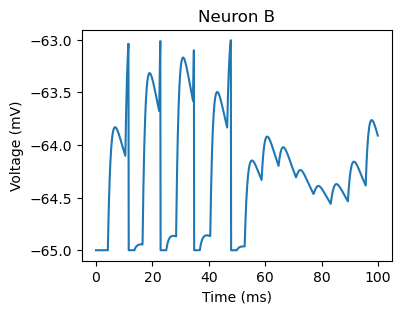

In [193]:
plt.figure(figsize=(4,3))
plt.plot(time,V_B)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Neuron B")
plt.show()

**Spike Train Neuron B**

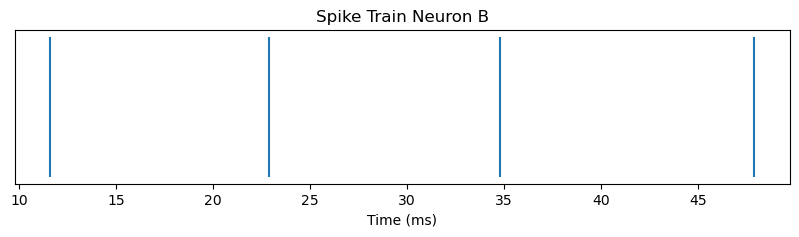

In [194]:
spike_times_B = time[spikes_B == 1]

plt.figure(figsize = (10,2))
plt.vlines(spike_times_B,ymin=0,ymax=1)
plt.xlabel("Time (ms)")
plt.yticks([])
plt.title("Spike Train Neuron B")
plt.show()

**Inter-Spike Interal (ISI)**

In [195]:
spike_times_A = time[spikes_A == 1]
spike_times_B = time[spikes_B == 1]

isi_A = np.diff(spike_times_A)
isi_B = np.diff(spike_times_B)

len(isi_A),len(isi_B)

(15, 3)

In [196]:
# mean ISI
mean_isi_A = np.mean(isi_A)
mean_isi_B = np.mean(isi_B)

mean_isi_A,mean_isi_B

(np.float64(6.093333333333334), np.float64(12.100000000000001))

In [197]:
# isi variance
std_isi_A = np.std(isi_A)
std_isi_B = np.std(isi_B)

std_isi_A,std_isi_B

(np.float64(0.10624918300339503), np.float64(0.7483314773547884))

In [198]:
# Coefficient of Variations (CV)
cv_A = np.std(isi_A)/ np.mean(isi_A)
cv_B = np.std(isi_B)/ np.mean(isi_B)
cv_A,cv_B

(np.float64(0.017436955635130473), np.float64(0.0618455766408916))

**Plot ISI for A**

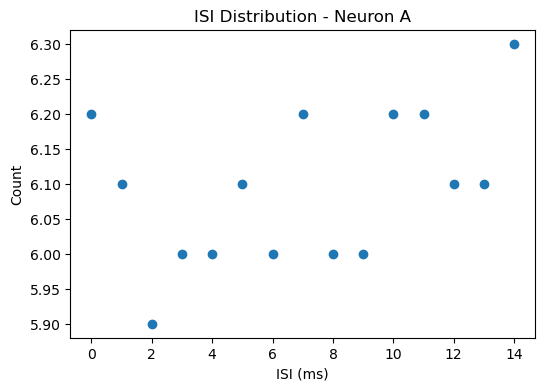

In [199]:
plt.figure(figsize=(6,4))
plt.plot(isi_A,'o')
plt.xlabel("ISI (ms)")
plt.ylabel("Count")
plt.title("ISI Distribution - Neuron A")
plt.show()

Plotting inter-spike intervals (ISI) as individual values shows that all ISIs collapse to a single constant value.
This indicates highly regular, tonic firing behavior of the neuron under constant input.
Such deterministic firing patterns are characteristic of LIF neurons without noise or time-varying inputs.
This regular baseline serves as a reference for later comparisons involving inhibition, noise, or modulation.

**Plot ISI for B**

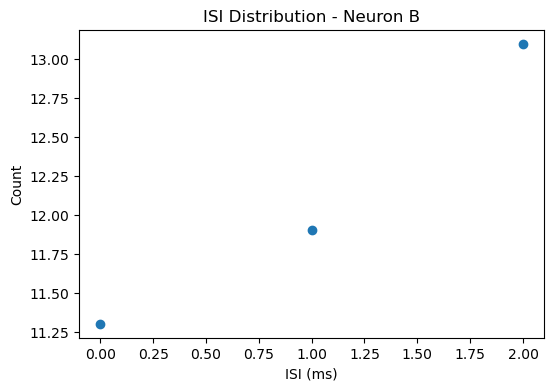

In [200]:
plt.figure(figsize=(6,4))
plt.plot(isi_B,'o')
plt.xlabel("ISI (ms)")
plt.ylabel("Count")
plt.title("ISI Distribution - Neuron B")
plt.show()

# Feature Vectors

In [201]:
# Feature Vector Neuron A
features_A = {
    "spike_count" : spike_count_A,
    "firing_rate" : firing_rate_A,
    "mean_isi" : np.mean(isi_A),
    "std_isi" : np.std(isi_A),
    "cv" : np.std(isi_A) / np.mean(isi_A)
}

features_A

{'spike_count': np.float64(16.0),
 'firing_rate': np.float64(160.0),
 'mean_isi': np.float64(6.093333333333334),
 'std_isi': np.float64(0.10624918300339503),
 'cv': np.float64(0.017436955635130473)}

In [202]:
# Feature Vector Neuron B
if len(isi_B) > 1:
    mean_isi_B = np.mean(isi_B)
    std_isi_B = np.std(isi_B)
    cv_B = std_isi_B / mean_isi_B
else:
    mean_isi_B = np.nan
    std_isi_B = np.nan
    cv_B = np.nan

features_B = {
    "spike_count" : spike_count_B,
    "firing_rate" : firing_rate_B,
    "mean_isi" : mean_isi_B,
    "std_isi" : std_isi_B,
    "cv" : cv_B
}

features_B

{'spike_count': np.float64(4.0),
 'firing_rate': np.float64(40.0),
 'mean_isi': np.float64(12.100000000000001),
 'std_isi': np.float64(0.7483314773547884),
 'cv': np.float64(0.0618455766408916)}

In [203]:
#Feature Table
import pandas as pd

feature_table = pd.DataFrame(
    [features_A,features_B],
    index=["Neuron_A", "Neuron_B"]
)
feature_table

,spike_count,firing_rate,mean_isi,std_isi,cv
Neuron_A,16.0,160.0,6.093333,0.106249,0.017437
Neuron_B,4.0,40.0,12.100000,0.748331,0.061846


## Simulation

In [204]:
input_currents = [2,4,6,8]
def run_simulation(I_value):
    V_rest = -65
    V_th = -63
    V_reset = -65
    tau = 10
    dt = 0.1
    T = 100
    time = np.arange(0, T, dt)
    noise_std = 1
    noise = np.random.normal(0,noise_std,len(time))

    V = np.zeros(len(time))
    V[0] = V_rest
    spikes = np.zeros(len(time))

    for t in range(1, len(time)):
        I_t = I_value + noise[t]
        dV = (-(V[t-1] - V_rest) + I_t) * (dt / tau)
        V[t] = V[t-1] + dV

        if V[t] >= V_th:
            spikes[t] = 1
            V[t] = V_reset

    spike_times = time[spikes == 1]
    isi = np.diff(spike_times)

    spike_count = np.sum(spikes)
    firing_rate = spike_count / (T / 1000)

    if len(isi) > 1:
        mean_isi = np.mean(isi)
        std_isi = np.std(isi)
        cv = std_isi / mean_isi
    else:
        mean_isi = std_isi = cv = np.nan

    return {
        "I": I_value,
        "spike_count": spike_count,
        "firing_rate": firing_rate,
        "mean_isi": mean_isi,
        "std_isi": std_isi,
        "cv": cv
    }

results = []

for I_val in input_currents:
    features = run_simulation(I_val)
    results.append(features)

dataset = pd.DataFrame(results)
dataset["label"] = (dataset["I"] >= 6).astype(int)
dataset

,I,spike_count,firing_rate,mean_isi,std_isi,cv,label
0,2,2.0,20.0,NaN,NaN,NaN,0
1,4,14.0,140.0,6.930769,0.229999,0.033185,0
2,6,24.0,240.0,4.117391,0.149353,0.036274,1
3,8,34.0,340.0,2.909091,0.079253,0.027243,1


In [205]:
dataset.describe()

,I,spike_count,firing_rate,mean_isi,std_isi,cv,label
count,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000,4.00000
mean,5.000000,18.500000,185.000000,4.652417,0.152868,0.032234,0.50000
std,2.581989,13.699148,136.991484,2.063532,0.075434,0.004590,0.57735
min,2.000000,2.000000,20.000000,2.909091,0.079253,0.027243,0.00000
25%,3.500000,11.000000,110.000000,3.513241,0.114303,0.030214,0.00000
50%,5.000000,19.000000,190.000000,4.117391,0.149353,0.033185,0.50000
75%,6.500000,26.500000,265.000000,5.524080,0.189676,0.034729,1.00000
max,8.000000,34.000000,340.000000,6.930769,0.229999,0.036274,1.00000


In [206]:
results_noise = []

for I_val in [2,4,6,8]:
    results_noise.append(run_simulation(I_val))

dataset_noise = pd.DataFrame(results_noise)
dataset_noise

,I,spike_count,firing_rate,mean_isi,std_isi,cv
0,2,2.0,20.0,NaN,NaN,NaN
1,4,14.0,140.0,6.876923,0.291294,0.042358
2,6,24.0,240.0,4.052174,0.134712,0.033244
3,8,34.0,340.0,2.890909,0.082988,0.028707


**Feature scaling & model**

In [207]:
features_noise = dataset_noise[["spike_count","firing_rate","mean_isi","std_isi","cv"]]
features_noise = features_noise.dropna()

scaler = StandardScaler()
X_noise = scaler.fit_transform(features_noise)

y_noise = (dataset_noise.loc[features_noise.index,"I"]>=6).astype(int)

model_noise = LogisticRegression()
model_noise.fit(X_noise,y_noise)

LogisticRegression()

In [208]:
importance_noise = pd.Series(
    model_noise.coef_[0],
    index=features_noise.columns
).sort_values(ascending=False)

importance_noise

spike_count    0.319366
firing_rate    0.319366
cv            -0.385177
mean_isi      -0.398790
std_isi       -0.411890
dtype: float64

[]

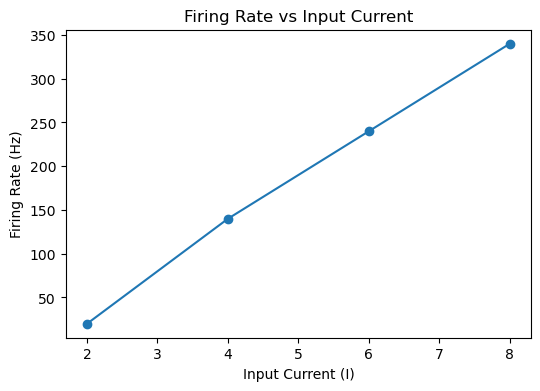

In [209]:
#Input current vs firing rate
plt.figure(figsize=(6,4))
plt.plot(dataset["I"],dataset["firing_rate"],marker='o')
plt.xlabel("Input Current (I)")
plt.ylabel("Firing Rate (Hz)")
plt.title("Firing Rate vs Input Current")
plt.plot()

[]

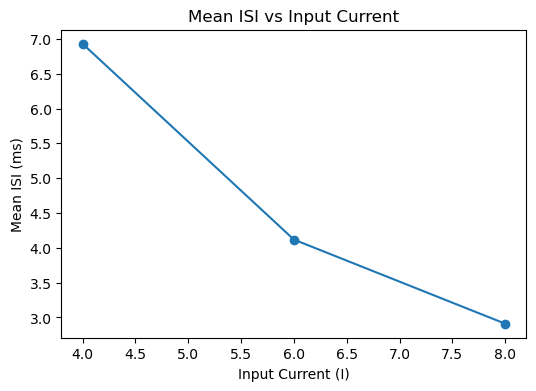

In [210]:
#Input Curent vs Mean ISI
plt.figure(figsize=(6,4))
plt.plot(dataset["I"],dataset["mean_isi"],marker='o')
plt.xlabel("Input Current (I)")
plt.ylabel("Mean ISI (ms)")
plt.title("Mean ISI vs Input Current")
plt.plot()

In [211]:
#Feature Correlation
dataset[["spike_count","firing_rate","mean_isi","std_isi","cv"]].corr()

,spike_count,firing_rate,mean_isi,std_isi,cv
spike_count,1.000000,1.000000,-0.974465,-0.999185,-0.647312
firing_rate,1.000000,1.000000,-0.974465,-0.999185,-0.647312
mean_isi,-0.974465,-0.974465,1.000000,0.982733,0.459633
std_isi,-0.999185,-0.999185,0.982733,1.000000,0.616023
cv,-0.647312,-0.647312,0.459633,0.616023,1.000000


## Feature Scaling

In [212]:
from sklearn.preprocessing import StandardScaler

features= dataset[["spike_count","firing_rate","mean_isi","std_isi","cv"]]

scaler = StandardScaler()
scaled_features= scaler.fit_transform(features)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

scaled_df

,spike_count,firing_rate,mean_isi,std_isi,cv
0,-1.390784,-1.390784,NaN,NaN,NaN
1,-0.379305,-0.379305,1.352245,1.252284,0.253818
2,0.463595,0.463595,-0.317548,-0.057074,1.077949
3,1.306494,1.306494,-1.034697,-1.195210,-1.331767


## Why Scaling matters ?

**Without scaling:**
- firing rate dominates
- ISI-bases features got ignored

**With scaling:**
- model can see all features
- interpretation becomes meaningful

## Handle NaNs

In [213]:
scaled_df.isna().sum()
X=scaled_df
y= dataset["label"]

valid_idx = ~scaled_df.isna().any(axis=1)
X_clean = scaled_df[valid_idx]
y_clean = y[valid_idx]

## Logistic Regression

In [214]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_clean,y_clean)

LogisticRegression()

## Predictions

In [215]:
predictions = model.predict(X_clean)
predictions

array([0, 1, 1])

In [216]:
y_clean.values

array([0, 1, 1])

## Accuracy

In [217]:
from sklearn.metrics import accuracy_score

accuracy_score(y_clean,predictions)

1.0

## Feature importance

In [218]:
importance = pd.Series(
    model.coef_[0],
    index=X_clean.columns
).sort_values(ascending=False)

importance

firing_rate    0.311514
spike_count    0.311514
cv             0.067799
std_isi       -0.471369
mean_isi      -0.547361
dtype: float64

## Re-state 

Before interpreting, anchor the experiment:

You simulated a LIF neuron

You varied input current

You extracted spike-based temporal features

You trained a simple linear classifier

The model separated low vs high input conditions

This is a controlled computational experiment, not random ML.

## Interpret feature importance

mean ISI (negative)

CV & std of ISI (positive)

spike count / firing rate


Interpret each one biologically.

🔹 Mean ISI — Primary signal

Higher input → faster membrane charging

Faster charging → shorter time between spikes

Therefore: mean ISI decreases with stronger input

🔹 ISI variability (CV, std) — Stability vs variability

Low input → near-threshold dynamics → irregular timing

High input → stable, fast spiking → less relative variability

🔹 Firing rate & spike count — Classic rate code

These features still matter:

Strong input → more spikes

This is expected and biologically valid


## Big neuroscience insight (THIS IS GOLD)

The results demonstrate:

Neural information is encoded jointly in firing rate and spike timing structure.

This directly aligns with:

temporal coding theories

population coding

computational neuroscience literature


## Why logistic regression was the right choice

Logistic regression was perfect because:

linear

interpretable

coefficients map directly to feature importance

For research, clarity > performance.

## Limitaions till now
- The dataset size is small
- Deterministic dynamics
- Single-neuron simulation model

# Observation
Introducing mild noise and small synaptic perturbations preserves the overall relationship between input strength and spike-based features.
While numerical values fluctuate, key trends in firing rate and temporal structure remain consistent.
This indicates that the observed feature–input relationships are robust and not artifacts of a specific parameter setting.

